## Finding Genvistau's prongness study

In [62]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()
import cmsstyle as CMS
import mplhep as hep
import matplotlib.pyplot as plt
sample = "/gv0/Users/achihwan/phase2/cmssw_16/condor/hltrun/new_150.root"
file = uproot.open(sample)
events = file["Events"]
runs = file["Runs"]
keys = events.keys()

In [73]:
import numpy as np
import awkward as ak

# =======================================================
# 1. 파일에서 전체 원본 데이터 불러오기
# =======================================================
gen_pt_all    = events["GenVisTau_pt"].array()
gen_eta_all   = events["GenVisTau_eta"].array()
gen_phi_all   = events["GenVisTau_phi"].array()
gen_prong_all = events["GenVisTau_status"].array()

reco_pt_all    = events["hltHpsPFTau_pt"].array()
reco_eta_all   = events["hltHpsPFTau_eta"].array()
reco_phi_all   = events["hltHpsPFTau_phi"].array()
reco_prong_all = events["hltHpsPFTau_decayMode"].array()

# =======================================================
# 2. 입자 단위 마스크 생성 및 필터링 (pT > 130 & |eta| < 2.1)
# =======================================================
gen_p_mask  = (gen_pt_all > 130) & (np.abs(gen_eta_all) < 2.1)
reco_p_mask = (reco_pt_all > 130) & (np.abs(reco_eta_all) < 2.1)

filtered_gen_pt    = gen_pt_all[gen_p_mask]
filtered_gen_eta   = gen_eta_all[gen_p_mask]
filtered_gen_phi   = gen_phi_all[gen_p_mask]
filtered_gen_prong = gen_prong_all[gen_p_mask]

filtered_reco_pt    = reco_pt_all[reco_p_mask]
filtered_reco_eta   = reco_eta_all[reco_p_mask]
filtered_reco_phi   = reco_phi_all[reco_p_mask]
filtered_reco_prong = reco_prong_all[reco_p_mask]

# =======================================================
# 3. 이벤트 단위 마스크 및 청정 데이터 추출
# =======================================================
both_mask = (ak.num(filtered_gen_pt) > 0) & (ak.num(filtered_reco_pt) > 0)

gen_pt_orig    = filtered_gen_pt[both_mask]
gen_eta_orig   = filtered_gen_eta[both_mask]
gen_phi_orig   = filtered_gen_phi[both_mask]
gen_prong_orig = filtered_gen_prong[both_mask]

reco_pt_orig    = filtered_reco_pt[both_mask]
reco_eta_orig   = filtered_reco_eta[both_mask]
reco_phi_orig   = filtered_reco_phi[both_mask]
reco_prong_orig = filtered_reco_prong[both_mask]

# =======================================================
# 4. 정렬 & 갯수 자르기 (Gen: 2개, Reco: 5개)
# =======================================================
gen_idx = ak.argsort(gen_pt_orig, axis=1, ascending=False)
gen_pt    = gen_pt_orig[gen_idx][:, :2]
gen_eta   = gen_eta_orig[gen_idx][:, :2]
gen_phi   = gen_phi_orig[gen_idx][:, :2]
gen_prong = gen_prong_orig[gen_idx][:, :2]

reco_idx = ak.argsort(reco_pt_orig, axis=1, ascending=False)
reco_pt    = reco_pt_orig[reco_idx][:, :5]
reco_eta   = reco_eta_orig[reco_idx][:, :5]
reco_phi   = reco_phi_orig[reco_idx][:, :5]
reco_prong = reco_prong_orig[reco_idx][:, :5]

# =======================================================
# 5. Cartesian Product 및 Delta R, Delta PT 매스킹
# =======================================================
pairs_pt    = ak.cartesian({"gen": gen_pt, "reco": reco_pt}, nested=True)
pairs_eta   = ak.cartesian({"gen": gen_eta, "reco": reco_eta}, nested=True)
pairs_phi   = ak.cartesian({"gen": gen_phi, "reco": reco_phi}, nested=True)
pairs_prong = ak.cartesian({"gen": gen_prong, "reco": reco_prong}, nested=True)

deta = pairs_eta.gen - pairs_eta.reco
dphi = pairs_phi.gen - pairs_phi.reco
dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
dr2  = deta**2 + dphi**2
dpt  = np.abs(pairs_pt.gen - pairs_pt.reco)

match_mask = (dr2 < (0.3**2)) & (dpt < 30)

# =======================================================
# 6. 매칭된 타우 추출 (첫 번째 Reco 선택)
# =======================================================
matched_reco_pt    = pairs_pt.reco[match_mask]
matched_reco_eta   = pairs_eta.reco[match_mask]
matched_reco_phi   = pairs_phi.reco[match_mask]
matched_reco_prong = pairs_prong.reco[match_mask]

first_reco_pt    = ak.firsts(matched_reco_pt, axis=2)
first_reco_eta   = ak.firsts(matched_reco_eta, axis=2)
first_reco_phi   = ak.firsts(matched_reco_phi, axis=2)
first_reco_prong = ak.firsts(matched_reco_prong, axis=2)

matched_results = ak.zip({
    "gen_pt": gen_pt,
    "gen_eta": gen_eta,
    "gen_phi": gen_phi,
    "gen_prong": gen_prong,
    "reco_pt": first_reco_pt,
    "reco_eta": first_reco_eta,
    "reco_phi": first_reco_phi,
    "reco_prong": first_reco_prong
})

# =======================================================
# 7. Unmatched / Same Prong / Diff Prong 분리
# =======================================================
is_unmatched = (ak.num(matched_reco_pt, axis=2) == 0)
is_matched   = ~is_unmatched

unmatched_tau = matched_results[is_unmatched]
valid_results = matched_results[is_matched]

matched_same = valid_results[valid_results.gen_prong == valid_results.reco_prong]
matched_diff = valid_results[valid_results.gen_prong != valid_results.reco_prong]

print("필터링 누수 여부 검증 (True가 나오면 안 됨):", ak.any(np.abs(matched_same.gen_eta) >= 2.1))


필터링 누수 여부 검증 (True가 나오면 안 됨): False


매칭 안 된 타우 개수 (flatten): 2346
매칭 완료 + Prong 같은 타우 개수: 4421
매칭 완료 + Prong 다른 타우 개수: 2757


In [67]:
print(f"매칭 안 된 타우 개수 (flatten): {len(ak.flatten(unmatched_tau.gen_pt))}")
print(ak.flatten(unmatched_tau.gen_prong))


print(f"매칭 완료 + Prong 같은 타우 개수: {len(ak.flatten(matched_same.gen_pt))}")
print(ak.flatten(matched_same.gen_prong))
print(ak.flatten(matched_same.reco_prong))

print(f"매칭 완료 + Prong 다른 타우 개수: {len(ak.flatten(matched_diff.gen_pt))}")
print(ak.flatten(matched_diff.gen_prong))
print(ak.flatten(matched_diff.reco_prong))

매칭 안 된 타우 개수 (flatten): 2346
[1, 11, 1, 10, 15, 11, 0, 1, 1, 1, 10, ..., 0, 10, 11, 11, 1, 2, 0, 15, 1, 10]
매칭 완료 + Prong 같은 타우 개수: 4421
[10, 0, 1, 0, 11, 1, 0, 10, 10, 11, 1, ..., 10, 1, 1, 1, 1, 1, 1, 1, 1, 11, 1]
[10, 0, 1, 0, 11, 1, 0, 10, 10, 11, 1, ..., 10, 1, 1, 1, 1, 1, 1, 1, 1, 11, 1]
매칭 완료 + Prong 다른 타우 개수: 2757
[2, 2, 2, 2, 15, 2, 11, 2, 2, 1, 2, 2, ..., 2, 2, 11, 11, 2, 0, 10, 2, 10, 1, 1]
[1, 1, 1, 1, 1, 1, 6, 1, 6, 11, 1, 1, ..., 1, 1, 1, 10, 10, 1, 1, 5, 1, 5, 0, 0]


In [74]:
import numpy as np

# ==========================================
# 1. 매칭 실패한 타우들의 Gen Prong 분포
# ==========================================
unmatched_prongs = ak.flatten(unmatched_tau.gen_prong)
vals, counts = np.unique(unmatched_prongs, return_counts=True)

print("=== [ 1. 매칭 실패 ] Gen Prong 분포 ===")
for v, c in zip(vals, counts):
    print(f" Gen Prong {v} : {c}개")


# ==========================================
# 2. 매칭 성공 & Prong 일치하는 타우 분포 (Gen == Reco)
# ==========================================
same_prongs = ak.flatten(matched_same.gen_prong)
vals, counts = np.unique(same_prongs, return_counts=True)

print("\n=== [ 2. 매칭 성공 & Prong 일치 ] 분포 ===")
for v, c in zip(vals, counts):
    print(f" Prong {v} -> {v} 매칭 : {c}번")


# ==========================================
# 3. 매칭 성공 & Prong 불일치하는 타우 분포
# ==========================================
diff_gen_prongs = ak.flatten(matched_diff.gen_prong)
diff_reco_prongs = ak.flatten(matched_diff.reco_prong)

print("\n=== [ 3-A. 매칭 성공 & Prong 불일치 ] 각각의 분포 ===")
v_gen, c_gen = np.unique(diff_gen_prongs, return_counts=True)
print(" < Gen Prong 측면 >")
for v, c in zip(v_gen, c_gen):
    print(f"  Gen Prong {v} : {c}개")

v_reco, c_reco = np.unique(diff_reco_prongs, return_counts=True)
print(" < Reco Prong 측면 >")
for v, c in zip(v_reco, c_reco):
    print(f"  Reco Prong {v} : {c}개")

# ------------------------------------------
# 💡 [핵심 보너스] 도대체 어떤 Gen이 어떤 Reco로 잘못 매칭(Migration) 되었을까?
# 쌍(Pair)으로 묶어서 2D 매트릭스 형태로 확인하기
# ------------------------------------------
print("\n=== [ 3-B. Prong 불일치 상세 조합(Pair) 분석 ] ===")
# Gen과 Reco 결과를 나란히 두 열로 묶음
pairs = np.column_stack((diff_gen_prongs, diff_reco_prongs))

# 묶여진 쌍(axis=0 기준)을 대상으로 unique를 적용
unique_pairs, pair_counts = np.unique(pairs, axis=0, return_counts=True)

for pair, cnt in zip(unique_pairs, pair_counts):
    print(f" Gen {pair[0]:.0f}-prong  ----(오인)---->  Reco {pair[1]:.0f}-prong : {cnt}번 발생")


=== [ 1. 매칭 실패 ] Gen Prong 분포 ===
 Gen Prong 0 : 234개
 Gen Prong 1 : 453개
 Gen Prong 2 : 218개
 Gen Prong 10 : 366개
 Gen Prong 11 : 209개
 Gen Prong 15 : 212개

=== [ 2. 매칭 성공 & Prong 일치 ] 분포 ===
 Prong 0 -> 0 매칭 : 543번
 Prong 1 -> 1 매칭 : 1878번
 Prong 10 -> 10 매칭 : 752번
 Prong 11 -> 11 매칭 : 273번

=== [ 3-A. 매칭 성공 & Prong 불일치 ] 각각의 분포 ===
 < Gen Prong 측면 >
  Gen Prong 0 : 104개
  Gen Prong 1 : 267개
  Gen Prong 2 : 1168개
  Gen Prong 10 : 194개
  Gen Prong 11 : 152개
  Gen Prong 15 : 345개
 < Reco Prong 측면 >
  Reco Prong 0 : 219개
  Reco Prong 1 : 1444개
  Reco Prong 2 : 1개
  Reco Prong 5 : 64개
  Reco Prong 6 : 234개
  Reco Prong 10 : 105개
  Reco Prong 11 : 163개

=== [ 3-B. Prong 불일치 상세 조합(Pair) 분석 ] ===
 Gen 0-prong  ----(오인)---->  Reco 1-prong : 102번 발생
 Gen 0-prong  ----(오인)---->  Reco 5-prong : 2번 발생
 Gen 1-prong  ----(오인)---->  Reco 0-prong : 182번 발생
 Gen 1-prong  ----(오인)---->  Reco 2-prong : 1번 발생
 Gen 1-prong  ----(오인)---->  Reco 5-prong : 7번 발생
 Gen 1-prong  ----(오인)---->  Reco 6-prong : 5

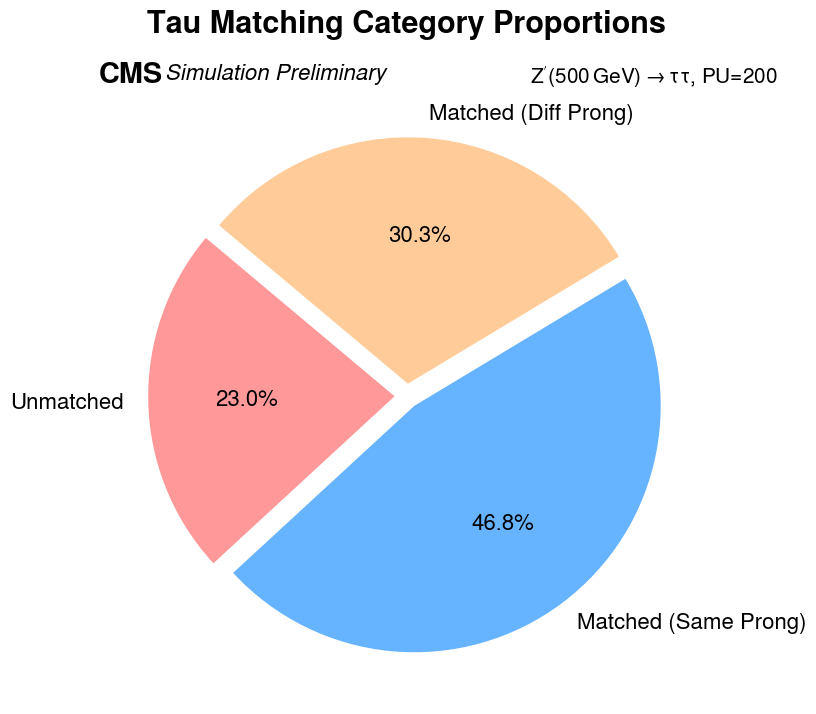

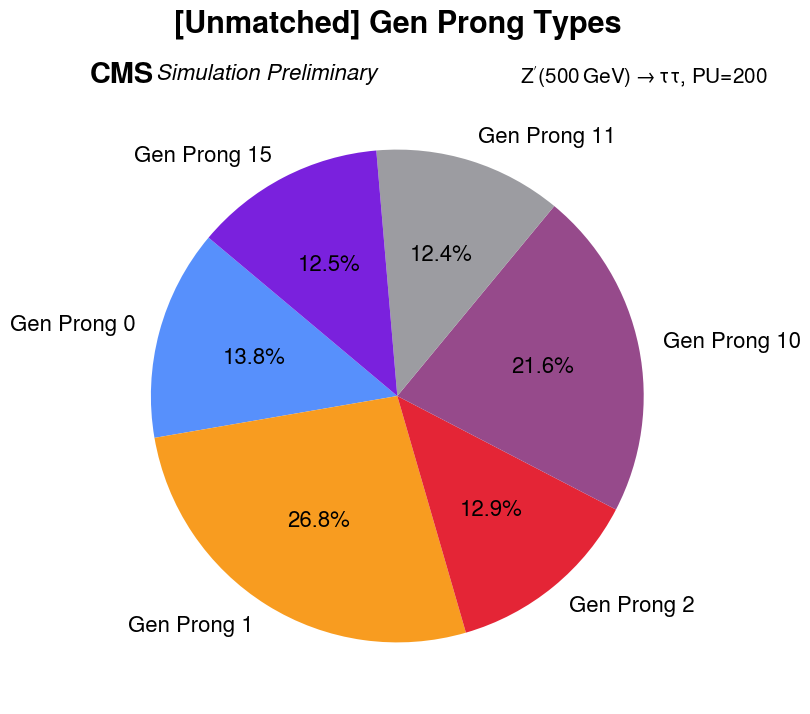

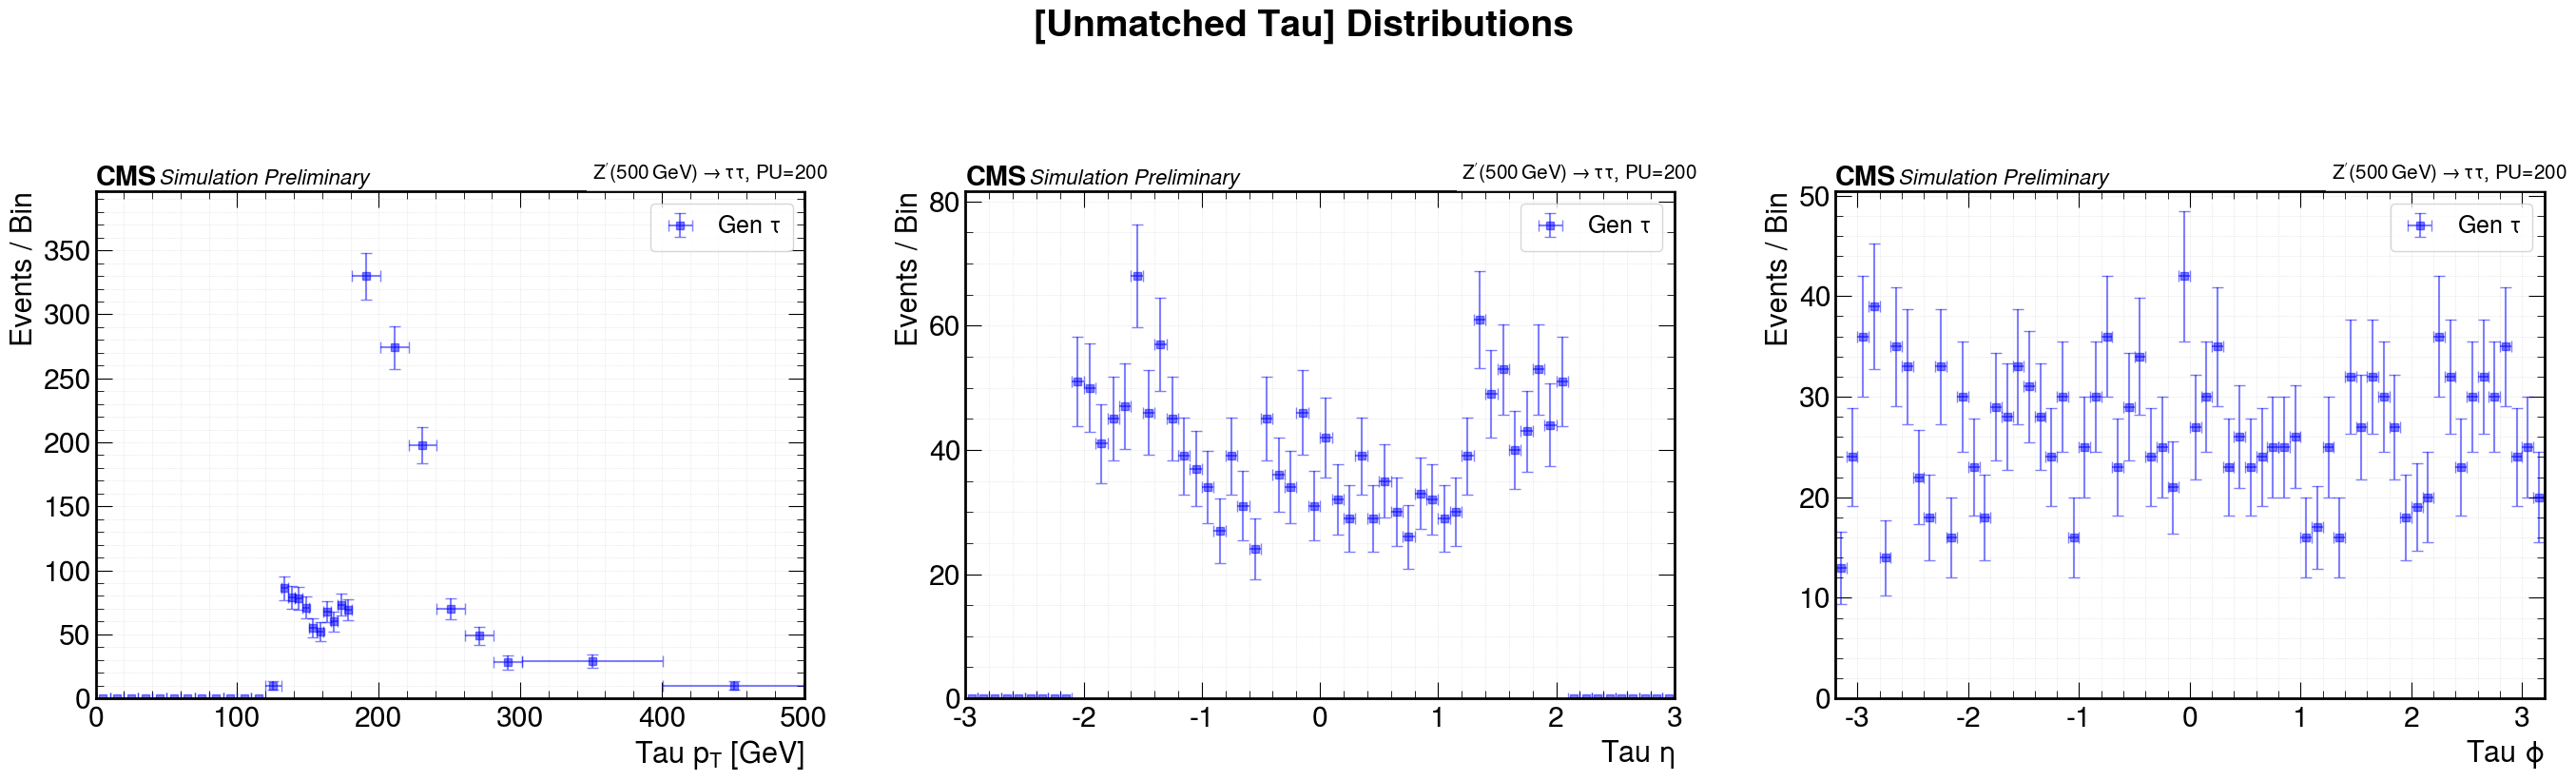

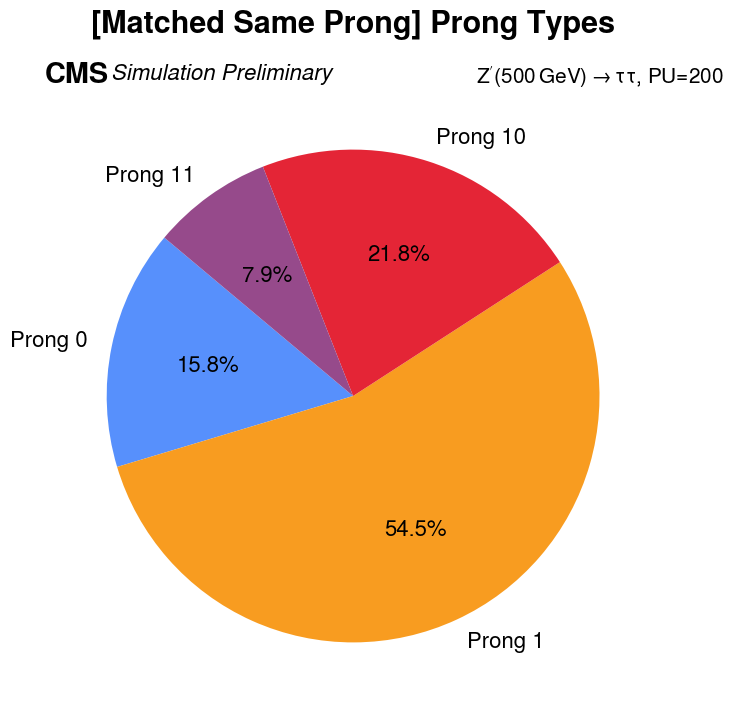

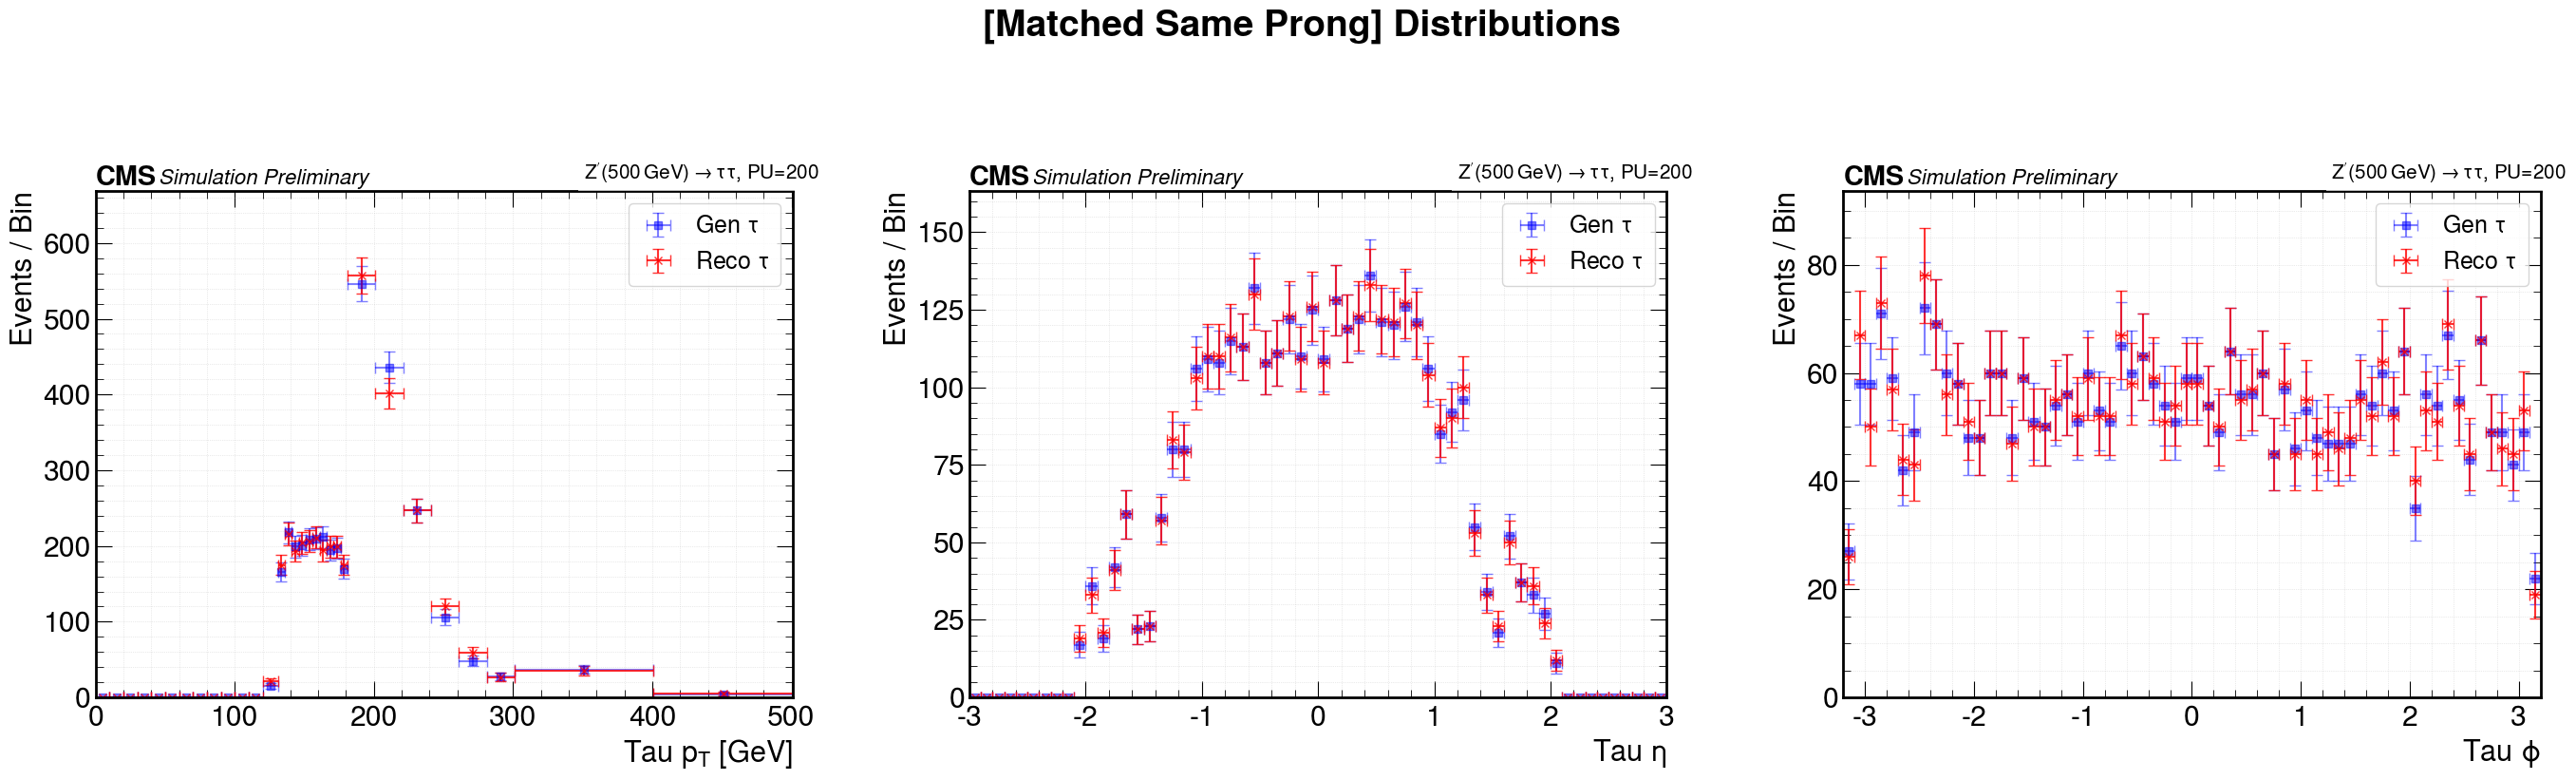

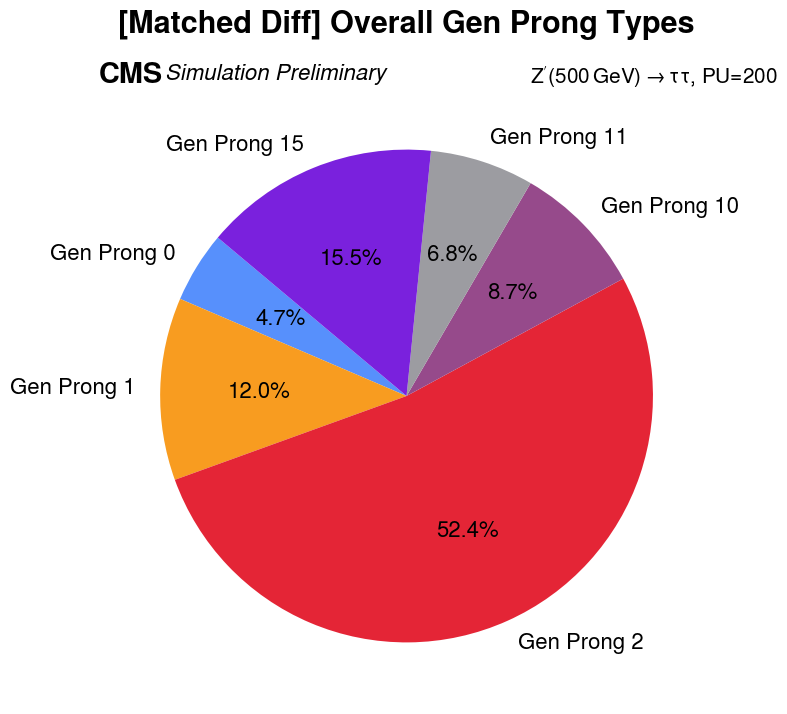

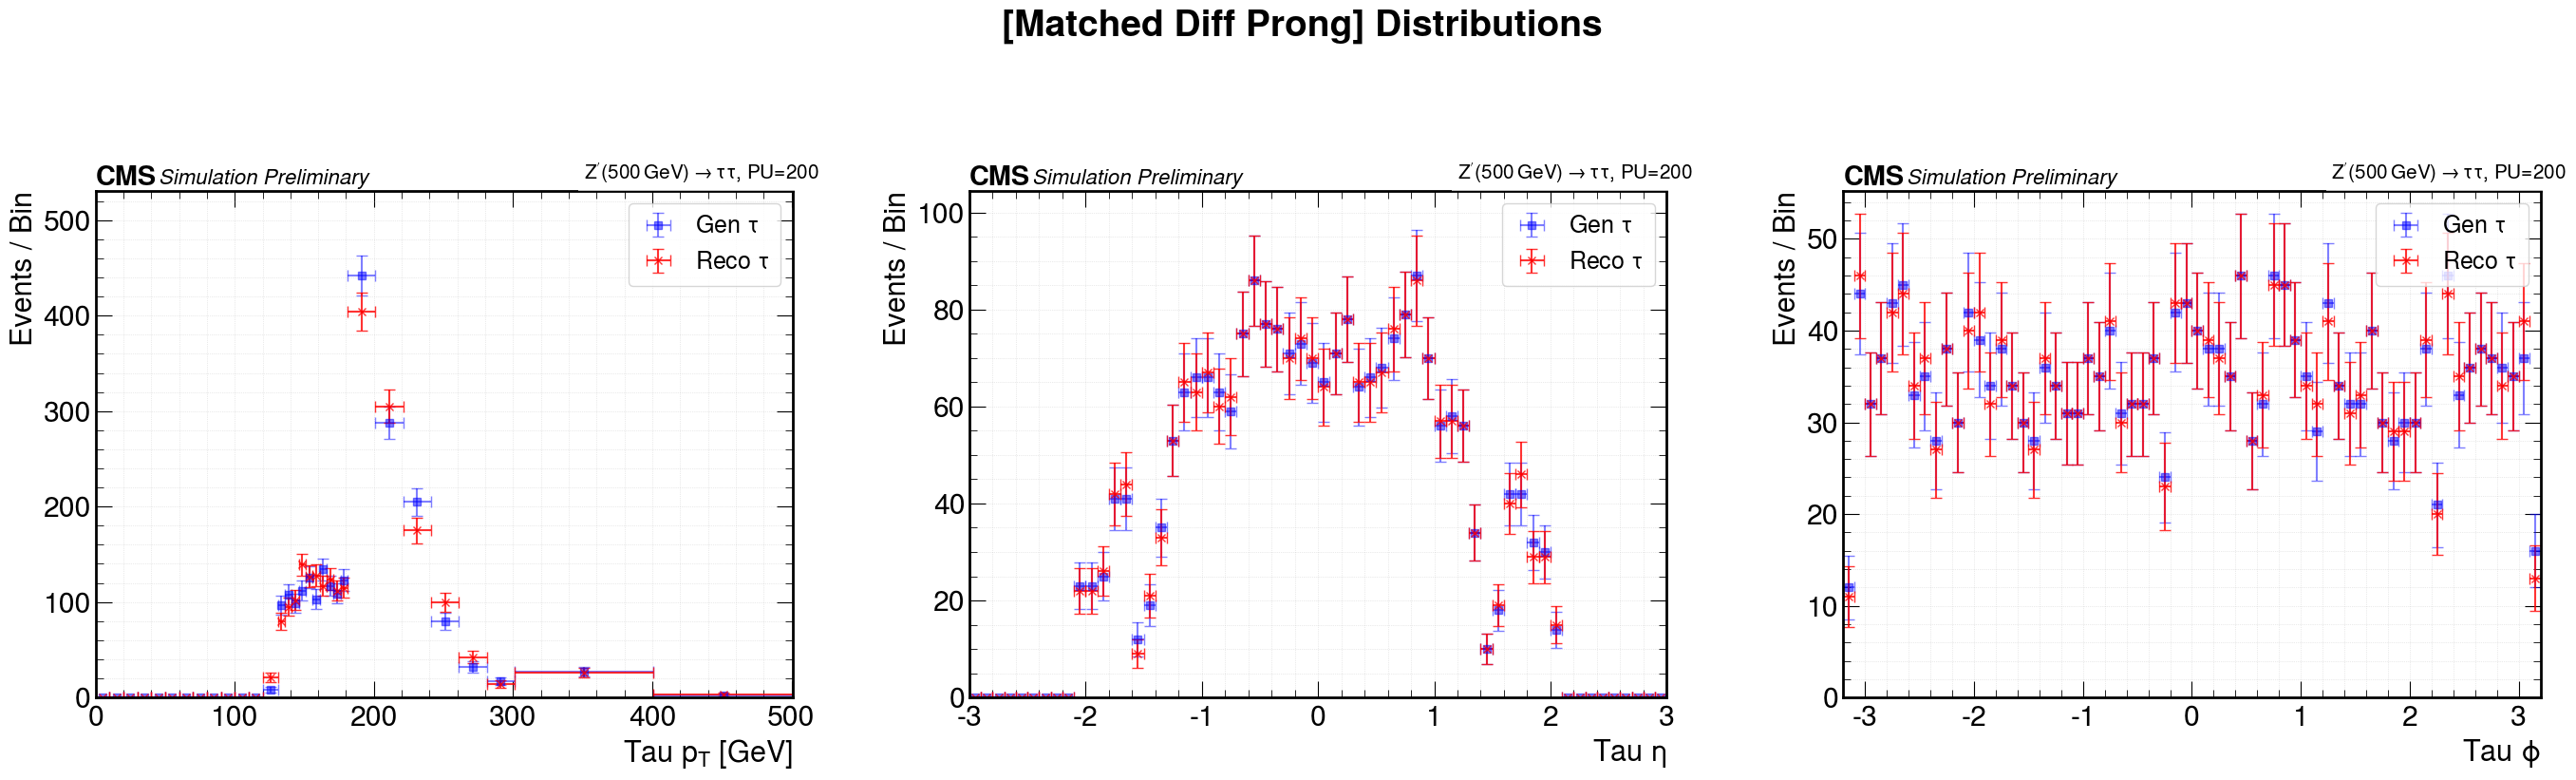

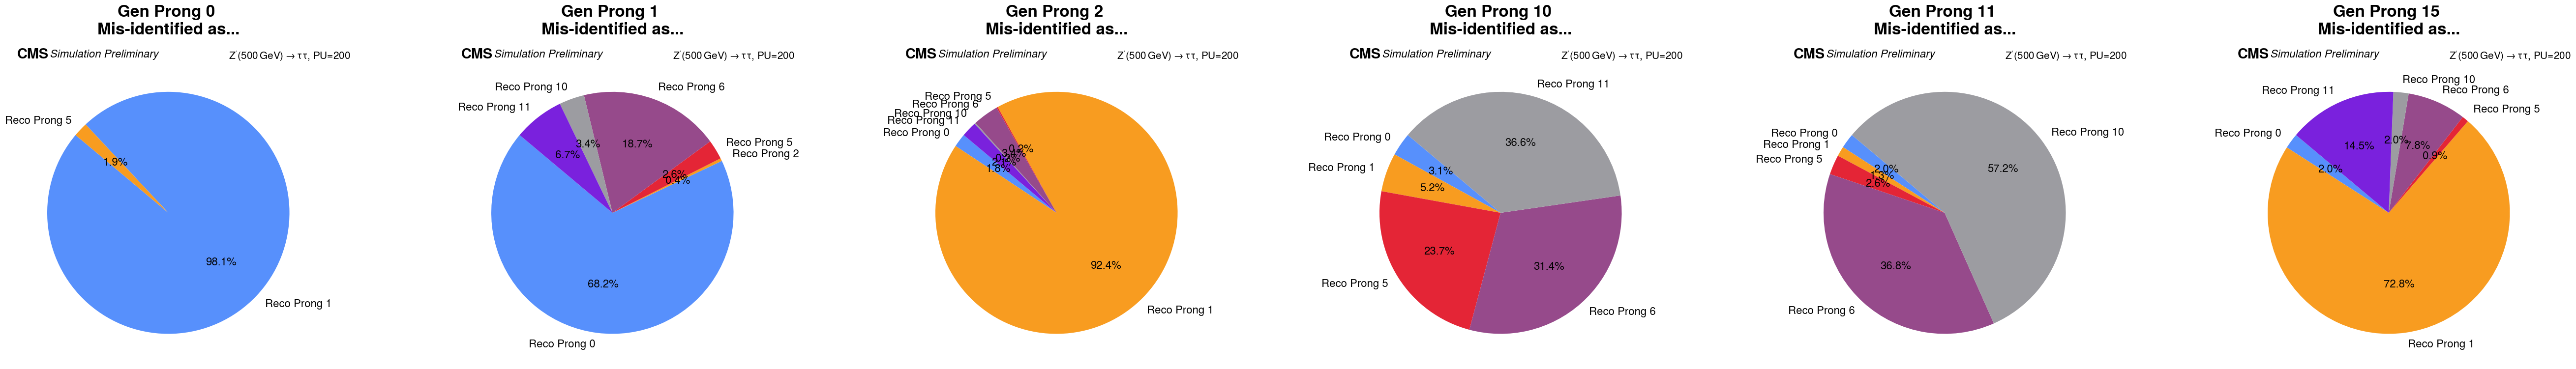

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import awkward as ak
import mplhep as hep

# ====================================================
# 전역 설정: CMS 스타일
# ====================================================
plt.style.use(hep.style.CMS)

def add_cms_info(ax, is_pie=False):
    """모든 그래프(히스토그램 & 파이)에 공통으로 들어갈 문구 추가"""
    # 좌상단 CMS Simulation ...
    hep.cms.text("Simulation Preliminary", loc=0, ax=ax, fontsize = 16)
    
    # 우상단 Z' 및 PU 설명 박스
    # 파이 차트는 원형이라 여백이 다르므로 위치(y좌표)를 약간 더 위로 올립니다.
    y_pos = 1.04 if is_pie else 1.06
    ax.text(0.7, y_pos, r"$Z'(500\,\mathrm{GeV}) \to \tau\tau$, PU=200",
            transform=ax.transAxes, fontsize=15, va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

def plot_pie_cms(counts, labels, title, explode=None, colors=None):
    """CMS 스타일의 깔끔한 파이 차트를 그리는 헬퍼 함수"""
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, 
           explode=explode, colors=colors, textprops={'fontsize': 16})
    # 제목 여백 넉넉히
    ax.set_title(title, pad=40, fontsize=22, fontweight='bold')
    
    # CMS 마크업 추가
    add_cms_info(ax, is_pie=True)
    plt.show()

# ====================================================
# [수정됨] PT, Eta, Phi를 포인트 + 에러바 형태로 그리는 함수
# ====================================================
def plot_kinematics_cms(gen_pt, gen_eta, gen_phi, reco_pt=None, reco_eta=None, reco_phi=None, title_prefix=""):
    fig, axes = plt.subplots(1, 3, figsize=(28, 8))
    
    # Bins
    bins_0 = np.arange(0, 130, 10)
    bins_1 = np.arange(131, 180, 5)
    bins_2 = np.arange(181, 300, 20)
    bins_3 = np.arange(301, 601, 100)
    bins_pt_custom = np.concatenate((bins_0, bins_1, bins_2, bins_3))
    
    bins_eta_custom = np.arange(-3.0, 3.1, 0.1)
    bins_phi_custom = np.arange(-3.2, 3.3, 0.1)
    
    # 에러바 플롯팅을 위한 내부 헬퍼 함수
    def draw_errorbar(ax, data_gen, data_reco, bins_array, xlabel):
        # 1. Gen 타우 계산 & 그리기 (Square 마커)
        counts_gen, edges = np.histogram(ak.flatten(data_gen), bins=bins_array)
        centers = (edges[:-1] + edges[1:]) / 2.0
        xerr = (edges[1:] - edges[:-1]) / 2.0
        yerr_gen = np.sqrt(counts_gen) # 이벤트 수 N에 대한 에러는 sqrt(N)
        
        ax.errorbar(centers, counts_gen, xerr=xerr, yerr=yerr_gen,
                    fmt='s', color='blue', ecolor='blue', capsize=4, alpha=0.5, label=r'Gen $\tau$')
        
        # 2. Reco 타우 계산 & 그리기 (Cross 마커)
        max_count = np.max(counts_gen)
        if data_reco is not None:
            counts_reco, _ = np.histogram(ak.flatten(data_reco), bins=bins_array)
            yerr_reco = np.sqrt(counts_reco)
            
            ax.errorbar(centers, counts_reco, xerr=xerr, yerr=yerr_reco,
                        fmt='x', color='red', ecolor='red', capsize=4, alpha=0.8, label=r'Reco $\tau$')
            max_count = max(max_count, np.max(counts_reco))
            
        # 축 및 디자인 설정
        ax.set_xlabel(xlabel, fontsize=22)
        ax.set_ylabel('Events / Bin', fontsize=22)
        ax.set_xlim(edges[0], edges[-1])
        # Y축 여유공간 20% 추가
        ax.set_ylim(0, max_count * 1.2)

    # 1) PT 그리기
    draw_errorbar(axes[0], gen_pt, reco_pt, bins_pt_custom, r'Tau $p_T$ [GeV]')
    # 2) ETA 그리기
    draw_errorbar(axes[1], gen_eta, reco_eta, bins_eta_custom, r'Tau $\eta$')
    # 3) PHI 그리기
    draw_errorbar(axes[2], gen_phi, reco_phi, bins_phi_custom, r'Tau $\phi$')

    # 개별 Subplot 전체 꾸미기 (CMS text, 범례 등)
    for ax in axes:
        add_cms_info(ax, is_pie=False)
        ax.legend(loc='upper right', fontsize=18, frameon=True)
        ax.grid(which='both', linestyle=':', linewidth=0.5, alpha=0.5)

    plt.suptitle(f"[{title_prefix}] Distributions", fontsize=28, y=1.05, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ====================================================
# [1번 미션] 전체 비율 파이 차트
# ====================================================
n_unmatched = len(ak.flatten(unmatched_tau.gen_pt))
n_same = len(ak.flatten(matched_same.gen_pt))
n_diff = len(ak.flatten(matched_diff.gen_pt))

plot_pie_cms([n_unmatched, n_same, n_diff], 
             labels=['Unmatched', 'Matched (Same Prong)', 'Matched (Diff Prong)'],
             title="Tau Matching Category Proportions", 
             colors=['#ff9999', '#66b3ff', '#ffcc99'], 
             explode=[0.05, 0.05, 0.05])

# ====================================================
# [2번 미션] Unmatched (Gen Prong 파이 + 히스토그램)
# ====================================================
vals, counts = np.unique(ak.flatten(unmatched_tau.gen_prong), return_counts=True)
plot_pie_cms(counts, labels=[f"Gen Prong {v}" for v in vals], title="[Unmatched] Gen Prong Types")

plot_kinematics_cms(unmatched_tau.gen_pt, unmatched_tau.gen_eta, unmatched_tau.gen_phi, title_prefix="Unmatched Tau")


# ====================================================
# [3번 미션] Matched Same Prong
# ====================================================
vals, counts = np.unique(ak.flatten(matched_same.gen_prong), return_counts=True)
plot_pie_cms(counts, labels=[f"Prong {v}" for v in vals], title="[Matched Same Prong] Prong Types")

plot_kinematics_cms(matched_same.gen_pt, matched_same.gen_eta, matched_same.gen_phi, 
                    reco_pt=matched_same.reco_pt, reco_eta=matched_same.reco_eta, reco_phi=matched_same.reco_phi, 
                    title_prefix="Matched Same Prong")


# ====================================================
# [4번 미션] Matched Diff Prong (종합 비율 + 세부 오인 파이 + 히스토그램)
# ====================================================
# 4-1. Matched Diff 내부의 전체 Gen Prong 비율
vals, counts = np.unique(ak.flatten(matched_diff.gen_prong), return_counts=True)
plot_pie_cms(counts, labels=[f"Gen Prong {v}" for v in vals], title="[Matched Diff] Overall Gen Prong Types")

# 4-2. 히스토그램
plot_kinematics_cms(matched_diff.gen_pt, matched_diff.gen_eta, matched_diff.gen_phi, 
                    reco_pt=matched_diff.reco_pt, reco_eta=matched_diff.reco_eta, reco_phi=matched_diff.reco_phi, 
                    title_prefix="Matched Diff Prong")

# 4-3. 핵심: 각 Gen Prong이 '무엇으로' 둔갑했는지 보여주는 개별 파이 차트
diff_gen = ak.flatten(matched_diff.gen_prong)
diff_reco = ak.flatten(matched_diff.reco_prong)
unique_gen_prongs = np.unique(diff_gen)

fig, axes = plt.subplots(1, len(unique_gen_prongs), figsize=(9 * len(unique_gen_prongs), 8))
if len(unique_gen_prongs) == 1: axes = [axes]

for ax, gen_p in zip(axes, unique_gen_prongs):
    mask = (diff_gen == gen_p)
    r_vals, r_counts = np.unique(diff_reco[mask], return_counts=True)
    
    ax.pie(r_counts, labels=[f"Reco Prong {v}" for v in r_vals], autopct='%1.1f%%', startangle=140, textprops={'fontsize': 16})
    ax.set_title(f"Gen Prong {gen_p} \nMis-identified as...", pad=40, fontsize=24, fontweight='bold')
    
    # 여기에도 각각 CMS 텍스트 적용
    add_cms_info(ax, is_pie=True)

plt.tight_layout()

plt.show()
